In [17]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt

In [18]:
df = pd.read_csv(
    "/content/nassau_candy_cleaned.csv"
)

print("Shape:", df.shape)
display(df.head())

Shape: (10194, 32)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Order Date Parsed,Ship Date Parsed,Lead Time Days,Profit Margin,Sales per Unit,Profit per Unit,Order Year,Order Month,Order Quarter,Order DayOfWeek
0,1,US-2021-103800-CHO-MIL-31000,3/1/2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,...,2024-01-03,2026-06-30,909,64.923077,3.25,2.11,2024,1,1,2
1,2,US-2021-112326-CHO-TRI-54000,4/1/2024,1/7/2026,Standard Class,112326,United States,Naperville,Illinois,60540,...,2024-01-04,2026-07-01,909,65.333333,3.75,2.45,2024,1,1,3
2,3,US-2021-112326-CHO-NUT-13000,4/1/2024,1/7/2026,Standard Class,112326,United States,Naperville,Illinois,60540,...,2024-01-04,2026-07-01,909,71.346705,3.49,2.49,2024,1,1,3
3,4,US-2021-112326-CHO-SCR-58000,4/1/2024,1/7/2026,Standard Class,112326,United States,Naperville,Illinois,60540,...,2024-01-04,2026-07-01,909,69.444444,3.60,2.50,2024,1,1,3
4,5,US-2021-141817-CHO-TRI-54000,5/1/2024,5/7/2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,...,2024-01-05,2026-07-05,912,65.333333,3.75,2.45,2024,1,1,4


In [19]:
target = "Lead Time Days"

X = df.drop(columns=[target])
y = df[target]

In [20]:
date_columns = [
    "Order Date Parsed",
    "Ship Date Parsed"
]

X = X.drop(
    columns=date_columns,
    errors="ignore"
)

In [21]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=[np.number]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name', 'Order Date Raw', 'Ship Date Raw']

Numerical features:
['Row ID', 'Customer ID', 'Sales', 'Units', 'Gross Profit', 'Cost', 'Calculated Gross Profit', 'Profit Difference', 'Profit Margin', 'Sales per Unit', 'Profit per Unit', 'Order Year', 'Order Month', 'Order Quarter', 'Order DayOfWeek']


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 8155
Testing rows: 2039


In [24]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [25]:
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(X_test)

In [26]:
def evaluate_model(name, actual, predicted):
    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    mae = mean_absolute_error(
        actual,
        predicted
    )

    r2 = r2_score(
        actual,
        predicted
    )

    return {
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

In [27]:
results = []

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_predictions
    )
)

pd.DataFrame(results)

,Model,RMSE,MAE,R2
0,Linear Regression,31.637521,16.625907,0.985847


In [28]:
preprocessor_rf = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [29]:
random_forest = Pipeline([
    ("preprocessor", preprocessor_rf),
    (
        "model",
        RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        )
    )
])

random_forest.fit(
    X_train,
    y_train
)

rf_predictions = random_forest.predict(X_test)

In [30]:
results.append(
    evaluate_model(
        "Random Forest Regressor",
        y_test,
        rf_predictions
    )
)

results_df = pd.DataFrame(results)

display(results_df)

,Model,RMSE,MAE,R2
0,Linear Regression,31.637521,16.625907,0.985847
1,Random Forest Regressor,0.729328,0.485289,0.999992


In [31]:
preprocessor_gb = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [32]:
gradient_boosting = Pipeline([
    ("preprocessor", preprocessor_gb),
    (
        "model",
        GradientBoostingRegressor(
            random_state=42
        )
    )
])

gradient_boosting.fit(
    X_train,
    y_train
)

gb_predictions = gradient_boosting.predict(X_test)

In [33]:
results.append(
    evaluate_model(
        "Gradient Boosting Regressor",
        y_test,
        gb_predictions
    )
)

results_df = pd.DataFrame(results)

display(results_df)

,Model,RMSE,MAE,R2
0,Linear Regression,31.637521,16.625907,0.985847
1,Random Forest Regressor,0.729328,0.485289,0.999992
2,Gradient Boosting Regressor,0.958714,0.781271,0.999987


In [34]:
results_df.sort_values(
    by="RMSE",
    ascending=True
)

,Model,RMSE,MAE,R2
1,Random Forest Regressor,0.729328,0.485289,0.999992
2,Gradient Boosting Regressor,0.958714,0.781271,0.999987
0,Linear Regression,31.637521,16.625907,0.985847


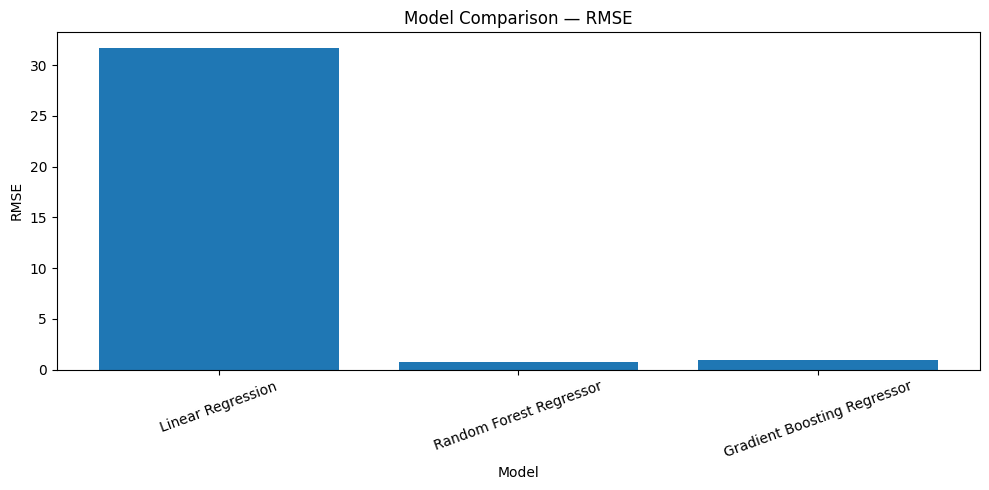

In [35]:
plt.figure(figsize=(10, 5))

plt.bar(
    results_df["Model"],
    results_df["RMSE"]
)

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Model Comparison — RMSE")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [36]:
best_predictions = rf_predictions
best_model = random_forest

In [37]:
best_predictions = gb_predictions
best_model = gradient_boosting

In [38]:
best_predictions = linear_predictions
best_model = linear_model

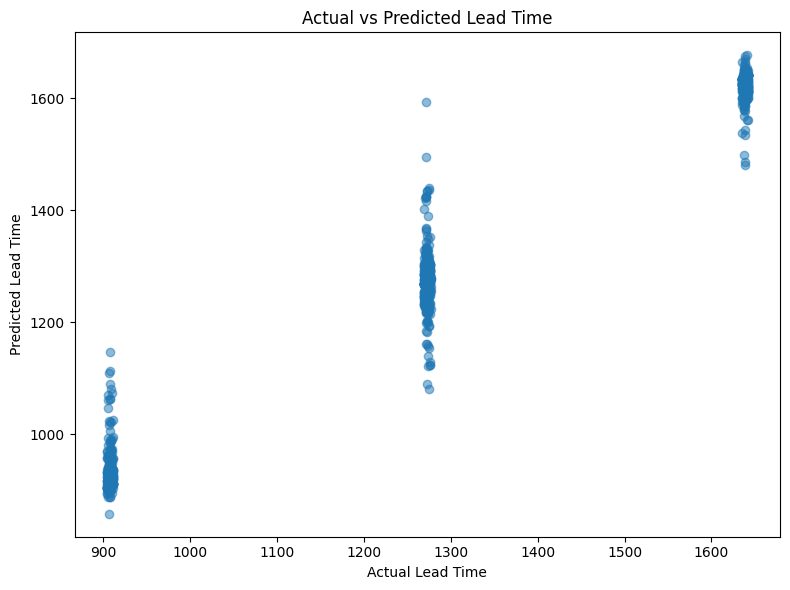

In [39]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.5
)

plt.xlabel("Actual Lead Time")
plt.ylabel("Predicted Lead Time")
plt.title("Actual vs Predicted Lead Time")

plt.tight_layout()
plt.show()

In [42]:
import os
import joblib

os.makedirs("../04_Models", exist_ok=True)

joblib.dump(
    best_model,
    "../04_Models/best_model.pkl"
)

print("Best model saved successfully.")

Best model saved successfully.


In [43]:
import os

print(os.path.exists("../04_Models/best_model.pkl"))

True


In [44]:
import joblib

joblib.dump(
    best_model,
    "../04_Models/best_model.pkl"
)

print("Best model saved successfully.")

Best model saved successfully.


In [45]:
import os
import joblib

# Show where Python is currently working
print("Current working directory:")
print(os.getcwd())

# Create 04_Models in the current working directory
models_folder = os.path.join(os.getcwd(), "04_Models")
os.makedirs(models_folder, exist_ok=True)

# Save the model
model_path = os.path.join(models_folder, "best_model.pkl")

joblib.dump(best_model, model_path)

print("\nModel saved successfully!")
print("Saved at:")
print(model_path)

# Verify
print("\nFile exists:", os.path.exists(model_path))
print("File size:", os.path.getsize(model_path), "bytes")

Current working directory:
/content

Model saved successfully!
Saved at:
/content/04_Models/best_model.pkl

File exists: True
File size: 388609 bytes


In [46]:
print(type(best_model))
print(best_model)

<class 'sklearn.pipeline.Pipeline'>
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Row ID', 'Customer ID',
                                                   'Sales', 'Units',
                                                   'Gross Profit', 'Cost',
                                                   'Calculated Gross Profit',
                                                   'Profit Difference',
                                                   'Profit Margin',
                                                   'Sales per Unit',
                                                   'Profit per Unit',
                                                   'Order Year', 'Order Month',
                                                   'Order Quarter',
                                                   'Order DayOfWeek']),
                                                 ('cat',
  

In [47]:
import os
import joblib

models_folder = os.path.join(os.getcwd(), "04_Models")
os.makedirs(models_folder, exist_ok=True)

model_path = os.path.join(models_folder, "best_model.pkl")

print("Saving model to:")
print(model_path)

joblib.dump(best_model, model_path)

print("Model saved!")

print("File exists:", os.path.isfile(model_path))

if os.path.isfile(model_path):
    print("File size:", os.path.getsize(model_path), "bytes")

Saving model to:
/content/04_Models/best_model.pkl
Model saved!
File exists: True
File size: 388609 bytes


In [48]:
import os

print(os.listdir(os.path.join(os.getcwd(), "04_Models")))

['best_model.pkl']
